In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import polars as pl
from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from scipy.stats import norm, t

In [ ]:
btc_ob = pl.LazyFrame(order_book_bnc_25)
btc_trades = pl.LazyFrame(trades_bnc)
btc_bbo = pl.LazyFrame(bbo_bnc)

In [ ]:
# btc_ob.collect().to_pandas().iloc[:1000, :].to_csv('btc_ob_sample.csv')
# btc_trades.collect().to_pandas().iloc[:10000, :].to_csv('btc_trades_sample.csv')
# btc_bbo.collect().to_pandas().iloc[:10000, :].to_csv('btc_bbo_sample.csv')

### Pre-Processing

In [ ]:
btc_trades.collect().describe()

statistic,human_time,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,recv_latency,next_recv_latency
str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""4682530""","""4682530""","""4682530""",4.68253e6,4.68253e6,4.68253e6,"""4682530""",4.68253e6,4.68253e6,4.68253e6,4.68253e6
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-03-23 14:44:12.056956""",null,null,1.7427e15,1.7427e15,2.2900e18,null,86133.056345,0.011495,46604.961877,46604.961263
"""std""",null,null,null,1.9518e11,1.9518e11,1.3518e6,null,1483.654369,0.056684,46401.786152,46401.786224
"""min""","""2025-03-20 00:00:00.080000""","""bybit-spot""","""BTCUSDT""",1.7424e15,1.7424e15,2.2900e18,"""buy""",83173.0,0.000001,37700.0,37700.0
"""25%""","""2025-03-21 07:50:11.208000""",null,null,1.7425e15,1.7425e15,2.2900e18,null,84581.33,0.000437,39854.0,39854.0
"""50%""","""2025-03-24 04:01:18.342000""",null,null,1.7428e15,1.7428e15,2.2900e18,null,86449.03,0.001708,40698.0,40698.0
"""75%""","""2025-03-25 14:09:42.162000""",null,null,1.7429e15,1.7429e15,2.2900e18,null,87417.0,0.009922,41865.0,41865.0
"""max""","""2025-03-26 23:59:59.441000""","""bybit-spot""","""BTCUSDT""",1.7430e15,1.7430e15,2.2900e18,"""sell""",88773.5,10.086762,2.226729e6,2.226729e6


计算每个Trades对应的Feature
1. 将Trades按照Timestamp打包groupby
2. 每一行变成timestamp，side，vwap，volume，slippage，book impact之类一系列值（每一行代表同一包的timestamp交易的信息）

3. 

In [ ]:


grouped_trades.describe()

NameError: name 'grouped_trades' is not defined

**Filter based on a hard-coded volume**

In [ ]:




filter_trades

volume_threshold: 0.003345


index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64
0,1742428800737532,2025-03-20 00:00:00.698,1742428800698000,86833.58,0.034536,86833.58,"""buy""",39532,1.6758e-12,-0.012855,0.000165,0.004785
1,1742428800932104,2025-03-20 00:00:00.892,1742428800892000,86833.58,0.039248,86833.58,"""buy""",40104,0.0,1.6758e-12,2.8084e-24,7.1556e-23
2,1742428800996300,2025-03-20 00:00:00.956,1742428800956000,86835.530568,0.00572,86835.27,"""buy""",40300,0.030007,0.224629,0.050458,8.821327
3,1742428801024202,2025-03-20 00:00:00.984,1742428800984000,86839.976391,0.006913,86839.62,"""buy""",40202,0.04104,0.511958,0.262101,37.914199
4,1742428801845049,2025-03-20 00:00:01.806,1742428801806000,86840.59,0.023237,86840.59,"""buy""",39049,0.0,0.070659,0.004993,0.214861
…,…,…,…,…,…,…,…,…,…,…,…,…
720017,1743033594811597,2025-03-26 23:59:54.771,1743033594771000,86895.21468,0.373983,86895.2,"""buy""",40597,0.001689,0.013197,0.000174,0.000466
720018,1743033594901133,2025-03-26 23:59:54.862,1743033594862000,86902.626098,0.008426,86901.0,"""buy""",39133,0.187121,0.852858,0.727366,86.324011
720019,1743033595752431,2025-03-26 23:59:55.713,1743033595713000,86904.5,0.0413,86904.5,"""sell""",39431,0.0,0.215628,0.046495,1.125795


### Spread Modelling

**Based on the number of valid trades, we choose the appropriate window. Feature window = 300 (10mins), vol window = 60 (2mins)**

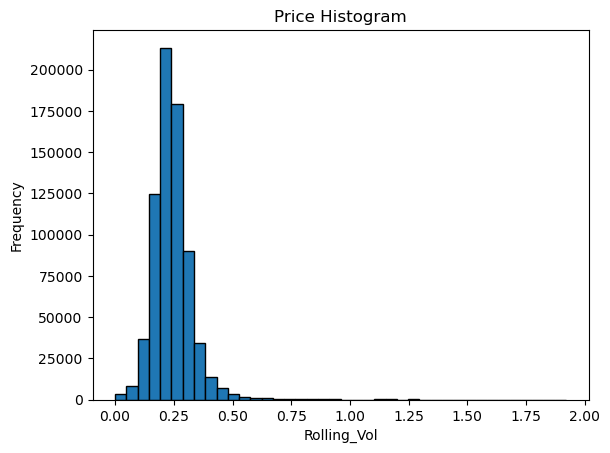

In [ ]:

vol_window = 60

spread_df = filter_trades.lazy().with_columns(
    pl.mean("vwap_diff_square").rolling(index_column="index", period=f"{vol_window}i").pow(0.5).alias(f'rolling_vol'),
).collect()

# Convert the 'price' column to a Pandas Series for plotting
price_data = spread_df['rolling_vol'].to_pandas()

# Plot histogram
plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
plt.title('Price Histogram')
plt.xlabel('Rolling_Vol')
plt.ylabel('Frequency')
plt.show()

**Beautiful plot, actually we can simply set the beta to be 4, so in normal case our spread is 1 + 4 * 0.25 = 2bps, and skew is also based on this**

### Feature Engineering

In [ ]:
spread_df

index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact,rolling_vol
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64
0,1742428800737532,2025-03-20 00:00:00.698,1742428800698000,86833.58,0.034536,86833.58,"""buy""",39532,1.6758e-12,-0.012855,0.000165,0.004785,0.012855
1,1742428800932104,2025-03-20 00:00:00.892,1742428800892000,86833.58,0.039248,86833.58,"""buy""",40104,0.0,1.6758e-12,2.8084e-24,7.1556e-23,0.00909
2,1742428800996300,2025-03-20 00:00:00.956,1742428800956000,86835.530568,0.00572,86835.27,"""buy""",40300,0.030007,0.224629,0.050458,8.821327,0.129902
3,1742428801024202,2025-03-20 00:00:00.984,1742428800984000,86839.976391,0.006913,86839.62,"""buy""",40202,0.04104,0.511958,0.262101,37.914199,0.279609
4,1742428801845049,2025-03-20 00:00:01.806,1742428801806000,86840.59,0.023237,86840.59,"""buy""",39049,0.0,0.070659,0.004993,0.214861,0.252078
…,…,…,…,…,…,…,…,…,…,…,…,…,…
720017,1743033594811597,2025-03-26 23:59:54.771,1743033594771000,86895.21468,0.373983,86895.2,"""buy""",40597,0.001689,0.013197,0.000174,0.000466,0.181869
720018,1743033594901133,2025-03-26 23:59:54.862,1743033594862000,86902.626098,0.008426,86901.0,"""buy""",39133,0.187121,0.852858,0.727366,86.324011,0.212601
720019,1743033595752431,2025-03-26 23:59:55.713,1743033595713000,86904.5,0.0413,86904.5,"""sell""",39431,0.0,0.215628,0.046495,1.125795,0.21441


In [ ]:
# Step1: 算下面的加和（rolling，难点只在于Side）
# 1. 每一行过去10次trade的 Buy Volume 加和，Sell Volume 加和
# 2. 每一行过去10次Buy Slippage 加和，Sell Slippage 加和
# 3. 上面两个数算Book Impact
# 4. Count 以及 Most Recent VWAP 在过去 1000 个 交易之中的

# Step2: 然后是算各自 z-score in past 1000
# Step3: 最后用LR算R^2

# Step4: 整理以上代码，将次数变成 1-500

In [ ]:
window = 100

df_fe_10 = spread_df.lazy().rolling(index_column="index", period=f"{window}i").agg(
    pl.col('local_timestamp').first(),
    pl.col('volume').filter(pl.col('side') == 'buy').sum().alias('buy_volume_sum'),
    pl.col('volume').filter(pl.col('side') == 'sell').sum().alias('sell_volume_sum'),
    pl.col('vwap_diff').filter(pl.col('side') == 'buy').sum().alias('buy_vwap_diff_sum'),
    pl.col('vwap_diff').filter(pl.col('side') == 'sell').sum().abs().alias('sell_vwap_diff_sum'),
    (pl.col('side').filter(pl.col('side') == 'buy').count() / window).alias('buy_count_ratio'),
    pl.col('vwap').last().alias('vwap')
).with_columns(
    ((pl.col('buy_vwap_diff_sum').pow(2)) / pl.col('buy_volume_sum')).alias('buy_book_impact'),
    ((pl.col('sell_vwap_diff_sum').pow(2)) / pl.col('sell_volume_sum')).alias('sell_book_impact'),
).collect()[window:].fill_nan(0)

In [ ]:
df_fe_10

NameError: name 'df_fe_10' is not defined

In [ ]:
# Filtering Outliers, 0.99 for winsorize

winsorize_threshold = 0.99 # 0.99通用

buy_volume_bound = df_fe_10.select(pl.col("buy_volume_sum").quantile(winsorize_threshold)).to_numpy()[0][0]
sell_volume_bound = df_fe_10.select(pl.col("sell_volume_sum").quantile(winsorize_threshold)).to_numpy()[0][0]

buy_vwap_diff_bound = df_fe_10.select(pl.col("buy_vwap_diff_sum").quantile(winsorize_threshold)).to_numpy()[0][0]
sell_vwap_diff_bound = df_fe_10.select(pl.col("sell_vwap_diff_sum").quantile(winsorize_threshold)).to_numpy()[0][0]

buy_book_impact_bound = df_fe_10.select(pl.col("buy_book_impact").quantile(winsorize_threshold)).to_numpy()[0][0]
sell_book_impact_bound = df_fe_10.select(pl.col("sell_book_impact").quantile(winsorize_threshold)).to_numpy()[0][0]

df_fe_10_w = df_fe_10.select(
    pl.col('local_timestamp'),
    pl.when(pl.col('buy_volume_sum') >= buy_volume_bound).then(high_volume_bound).otherwise(pl.col('buy_volume_sum')).alias('buy_volume_sum'),
    pl.when(pl.col('sell_volume_sum') >= sell_volume_bound).then(sell_volume_bound).otherwise(pl.col('sell_volume_sum')).alias('sell_volume_sum'),
    
    pl.when(pl.col('buy_vwap_diff_sum') >= buy_vwap_diff_bound).then(buy_vwap_diff_bound).otherwise(pl.col('buy_vwap_diff_sum')).alias('buy_vwap_diff_sum'),
    pl.when(pl.col('sell_vwap_diff_sum') >= sell_vwap_diff_bound).then(sell_vwap_diff_bound).otherwise(pl.col('sell_vwap_diff_sum')).alias('sell_vwap_diff_sum'),
    
    pl.when(pl.col('buy_book_impact') >= buy_book_impact_bound).then(buy_book_impact_bound).otherwise(pl.col('buy_book_impact')).alias('buy_book_impact'),
    pl.when(pl.col('sell_book_impact') >= sell_book_impact_bound).then(sell_book_impact_bound).otherwise(pl.col('sell_book_impact')).alias('sell_book_impact'),
    
    pl.col('vwap').alias('vwap'),
    pl.col('buy_count_ratio').alias('buy_count_ratio')
).with_row_index()

In [ ]:
df_fe_10_w

index,local_timestamp,buy_volume_sum,sell_volume_sum,buy_vwap_diff_sum,sell_vwap_diff_sum,buy_book_impact,sell_book_impact,vwap,buy_count_ratio
u32,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,1742428800932104,4.382748,5.743542,11.97762,2.483921,32.733657,1.074226,86916.057288,0.79
1,1742428800996300,4.3435,5.770462,11.97762,2.032619,33.02944,0.715981,86919.98,0.78
2,1742428801024202,4.344669,5.770462,12.190526,2.032619,34.204892,0.715981,86923.783124,0.78
3,1742428801845049,4.37442,5.770462,11.972711,2.032619,32.769103,0.715981,86926.34,0.78
4,1742428802645626,4.351183,5.775106,11.902052,2.03377,32.556398,0.716215,86926.33,0.77
…,…,…,…,…,…,…,…,…,…
719917,1743033339080282,2.590925,5.512138,3.827031,3.882961,5.65287,2.735306,86895.21468,0.34
719918,1743033339113201,2.567551,5.512138,4.679888,3.882961,8.530056,2.735306,86902.626098,0.34
719919,1743033339120375,2.545751,5.553438,4.679888,3.667333,8.603101,2.421803,86904.5,0.33


In [ ]:
df_fe_10_z

index,local_timestamp,buy_vm_z_score,sell_vm_z_score,buy_vd_z_score,sell_vd_z_score,buy_bi_z_score,sell_bi_z_score,vwap_z_score,bcount_z_score
u32,i64,f64,f64,f64,f64,f64,f64,f64,f64
1000,1742428800996300,1.041068,-1.288714,0.254409,-1.44594,-0.427059,-1.148855,2.277491,1.980371
1001,1742428801024202,1.054596,-1.287313,-0.106858,-1.445044,-0.601332,-1.148965,2.280617,1.976622
1002,1742428801845049,1.033087,-1.285928,-0.072604,-1.444149,-0.578464,-1.149076,2.280083,1.972891
1003,1742428802645626,1.035088,-1.284557,-0.00119,-1.443255,-0.546527,-1.149187,2.286992,1.969175
1004,1742428802646498,1.040434,-1.283206,0.149357,-1.442361,-0.477944,-1.149298,2.310351,1.965302
…,…,…,…,…,…,…,…,…,…
719917,1743032113607314,-0.18805,1.450175,-0.884447,-0.460827,-0.903829,-0.782045,0.888791,-1.216674
719918,1743032117918567,-0.204359,1.448015,-0.504119,-0.45936,-0.620291,-0.780571,1.10887,-1.216935
719919,1743032118361781,-0.219622,1.472277,-0.505363,-0.544037,-0.613515,-0.80751,1.163318,-1.319235


In [1007]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     44.63
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           5.02e-70
Time:                        18:25:20   Log-Likelihood:                -21884.
No. Observations:                5746   AIC:                         4.379e+04
Df Residuals:                    5737   BIC:                         4.385e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3341      0.146     

In [1027]:
import statsmodels.api as sm



                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.437
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           0.000595
Time:                        18:27:17   Log-Likelihood:                -22050.
No. Observations:                5746   AIC:                         4.411e+04
Df Residuals:                    5743   BIC:                         4.413e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3550      0.148     

In [951]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     47.55
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           1.03e-74
Time:                        18:19:27   Log-Likelihood:                -21870.
No. Observations:                5745   AIC:                         4.376e+04
Df Residuals:                    5736   BIC:                         4.382e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3203      0.148     

In [967]:
import statsmodels.api as sm

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     41.24
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           1.43e-64
Time:                        18:20:22   Log-Likelihood:                -21886.
No. Observations:                5743   AIC:                         4.379e+04
Df Residuals:                    5734   BIC:                         4.385e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3172      0.147     

In [991]:

df = final_df.to_pandas()

# Define the feature columns and the target column
X = df[['buy_vm_z_score', 'sell_vm_z_score', 'buy_vd_z_score', 'sell_vd_z_score', 'buy_bi_z_score', 'sell_bi_z_score', 'vwap_z_score', 'bcount_z_score']]  # Feature columns
y = df['target_return_bps']  # Target column

# Add a constant column (intercept) to the feature columns for statsmodels
X = sm.add_constant(X)

# Fit the model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Print the detailed summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      target_return_bps   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     33.51
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           4.51e-52
Time:                        18:24:37   Log-Likelihood:                -21927.
No. Observations:                5746   AIC:                         4.387e+04
Df Residuals:                    5737   BIC:                         4.393e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3444      0.145     

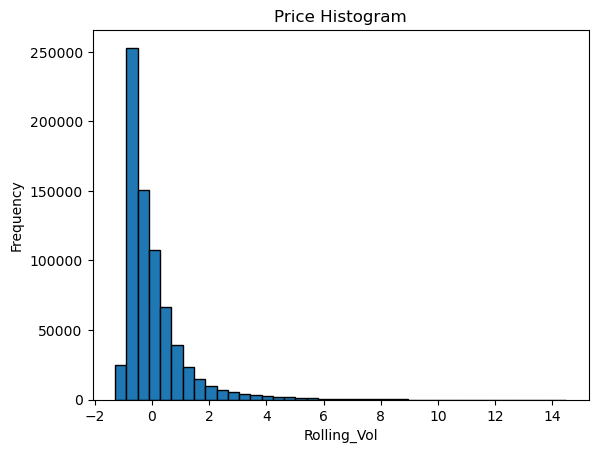

In [812]:
# Convert the 'price' column to a Pandas Series for plotting
price_data = df_fe_10_z['buy_vm_z_score'].to_pandas()

# Plot histogram
plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
plt.title('Price Histogram')
plt.xlabel('Rolling_Vol')
plt.ylabel('Frequency')
plt.show()

### Observation Sampling and Target Variable

**Get rolling price diff within 15ms for observation sampling**

In [607]:
return_window = 15000

df_os_1 = spread_df.lazy().with_columns(
    pl.first("vwap").rolling(index_column="exch_time", period=f"{return_window}i").alias(f'rolling_10ms_vwap')
).with_columns(
    ((pl.col('vwap') - pl.col('rolling_10ms_vwap')) / pl.col('vwap') * 10000).alias(f'rolling_10ms_vwap_diff')
).with_columns(
    pl.max_horizontal(
        pl.col('rolling_10ms_vwap_diff').abs(),
        pl.col('vwap_diff').abs()
    ).alias('max_delta')
).collect()

In [859]:
beta_vol = 2
fixed_spread = 0.5

return_df = df_os_1.lazy().with_columns(
    (pl.col("rolling_vol") * beta_vol + fixed_spread).alias('spread')
).collect()

valid_df = return_df.filter(
    (pl.col('max_delta').abs() >= pl.col('spread'))
).with_columns(
    (pl.col("rolling_10ms_vwap").diff().abs() / pl.col("rolling_10ms_vwap") * 10000).alias('diff_between_two_dp')
).filter(
    pl.col('diff_between_two_dp') >= 0.5
).with_columns(
    (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('bucket_id')
)

In [861]:
valid_df

index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact,rolling_vol,rolling_10ms_vwap,rolling_10ms_vwap_diff,max_delta,spread,diff_between_two_dp,bucket_id
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
38,1742428809625727,2025-03-20 00:00:09.585,1742428809585000,86862.88,0.003407,86862.88,"""sell""",40727,0.0,-0.857386,0.735111,215.765011,0.455214,86878.307718,-1.7761,1.7761,1.410429,0.719718,0
109,1742428817617049,2025-03-20 00:00:17.577,1742428817577000,86935.03,0.102067,86935.03,"""buy""",40049,1.6739e-12,0.107176,0.011487,0.112542,0.232938,86926.34052,0.999537,0.999537,0.965876,5.52569,1
119,1742428818258641,2025-03-20 00:00:18.217,1742428818217000,86904.77,0.013701,86904.77,"""sell""",41641,0.0,-0.628274,0.394728,28.810168,0.349287,86917.47827,-1.462321,1.462321,1.198574,1.019617,2
147,1742428829775730,2025-03-20 00:00:29.733,1742428829733000,86889.449342,0.40356,86894.99,"""sell""",42730,0.637627,-1.50362,2.260873,5.602321,0.492419,86902.515044,-1.503716,1.503716,1.484839,1.72184,2
307,1742428922255423,2025-03-20 00:02:02.215,1742428922215000,86906.534582,0.008278,86904.77,"""buy""",40423,0.203048,0.663086,0.439683,53.114672,0.387984,86894.838132,1.345865,1.345865,1.275967,0.883472,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
719216,1743032465170245,2025-03-26 23:41:05.131,1743032465131000,86857.130331,0.4562,86859.5,"""sell""",39245,0.272816,-0.272855,0.07445,0.163196,0.202237,86865.477507,-0.961024,0.961024,0.904474,1.556717,2026
719340,1743032538102772,2025-03-26 23:42:18.059,1743032538059000,86837.010708,1.021516,86835.1,"""buy""",43772,0.220039,0.594046,0.35289,0.345457,0.329965,86826.7,1.187363,1.187363,1.15993,3.639433,2027
719683,1743033082766758,2025-03-26 23:51:22.683,1743033082683000,86855.196936,0.312152,86853.9,"""buy""",83758,0.149324,0.195235,0.038117,0.122109,0.240138,86846.2,1.035855,1.035855,0.980276,2.245349,2027


In [865]:
target_price = valid_df.with_columns(
    (pl.col('bucket_id') - 1).alias('bucket_id')
).group_by('bucket_id').agg(
    pl.col('vwap').first().alias('next_trade_price')
)

test = valid_df.join(target_price, on='bucket_id', how='left').drop_nulls().with_columns(
    ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
)

In [883]:
test

index,local_timestamp,human_time,exch_time,vwap,volume,initial_price,side,recv_latency,slippage,vwap_diff,vwap_diff_square,book_impact,rolling_vol,rolling_10ms_vwap,rolling_10ms_vwap_diff,max_delta,spread,diff_between_two_dp,bucket_id,next_trade_price,target_return_bps
u32,i64,datetime[μs],i64,f64,f64,f64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64
38,1742428809625727,2025-03-20 00:00:09.585,1742428809585000,86862.88,0.003407,86862.88,"""sell""",40727,0.0,-0.857386,0.735111,215.765011,0.455214,86878.307718,-1.7761,1.7761,1.410429,0.719718,0,86935.03,-8.306195
109,1742428817617049,2025-03-20 00:00:17.577,1742428817577000,86935.03,0.102067,86935.03,"""buy""",40049,1.6739e-12,0.107176,0.011487,0.112542,0.232938,86926.34052,0.999537,0.999537,0.965876,5.52569,1,86904.77,3.48076
119,1742428818258641,2025-03-20 00:00:18.217,1742428818217000,86904.77,0.013701,86904.77,"""sell""",41641,0.0,-0.628274,0.394728,28.810168,0.349287,86917.47827,-1.462321,1.462321,1.198574,1.019617,2,86906.534582,-0.203048
147,1742428829775730,2025-03-20 00:00:29.733,1742428829733000,86889.449342,0.40356,86894.99,"""sell""",42730,0.637627,-1.50362,2.260873,5.602321,0.492419,86902.515044,-1.503716,1.503716,1.484839,1.72184,2,86906.534582,-1.966319
307,1742428922255423,2025-03-20 00:02:02.215,1742428922215000,86906.534582,0.008278,86904.77,"""buy""",40423,0.203048,0.663086,0.439683,53.114672,0.387984,86894.838132,1.345865,1.345865,1.275967,0.883472,3,86963.902636,-6.601121
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
718810,1743031998156312,2025-03-26 23:33:18.115,1743031998115000,86823.078549,0.086855,86824.8,"""sell""",41312,0.198267,-0.458166,0.209916,2.416858,0.177749,86831.490771,-0.968892,0.968892,0.855498,13.815861,2026,86837.010708,-1.604661
718914,1743032107433154,2025-03-26 23:35:07.394,1743032107394000,86850.6,0.0197,86850.6,"""sell""",39154,1.6755e-12,-1.148048,1.318015,66.904291,0.28707,86850.6,0.0,1.148048,1.074139,2.200241,2026,86837.010708,1.564674
719036,1743032288873311,2025-03-26 23:38:08.826,1743032288826000,86798.341141,0.1975,86800.6,"""sell""",47311,0.260235,-0.608444,0.370204,1.874448,0.298468,86810.7,-1.423859,1.423859,1.096937,4.596208,2026,86837.010708,-4.455104


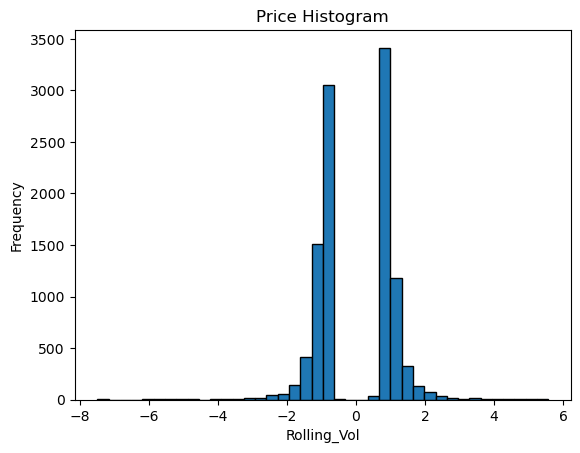

In [592]:
plot_df = test_.filter(
    (pl.col('vwap_diff').abs() >= pl.col('spread'))
)

# Convert the 'price' column to a Pandas Series for plotting
price_data = plot_df['vwap_diff'].to_pandas()

# Plot histogram
plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
plt.title('Price Histogram')
plt.xlabel('Rolling_Vol')
plt.ylabel('Frequency')
plt.show()

这个案例很有意思，思考两个问题

1. Swing如果用VWAP Diff的话，的确我们会在这些地方成交，但是可能大部分都是反转交易了（之前的一系列buy是否无法预测，反而因为样本选取的原因，导致模型错误认为一系列buy后面会导致sell？） - 是否应该用slippage，或者单纯就选量大的就好。
2. 关于timestamp聚集的情况，这些timestamp靠的非常紧，肯定有一些数据是后面看不到的，我们应该怎么来建模，仔细揣摩这些交易流，然后产生灵感哪些feature可能会有用

加油，你离真相越来越近了，系统在一步步完善了！

In [ ]:
grouped_trades.sort('timestamp').filter(pl.col('timestamp') >= 1742429049018000).to_pandas()[:20]

,timestamp,human_time,vwap,volume,initial_price,side,recv_latency,slippage,book_impact
0,1742429049018000,2025-03-20 00:04:09.018,87358.370179,0.183396,87356.53,buy,41250,2.106516e-01,0.2
1,1742429049019000,2025-03-20 00:04:09.019,87369.586163,0.016588,87368.85,buy,40582,8.425926e-02,0.4
2,1742429049021000,2025-03-20 00:04:09.021,87383.778113,1.582000,87369.59,buy,43435,1.623919e+00,1.7
3,1742429049031000,2025-03-20 00:04:09.031,87393.070009,0.250000,87367.95,buy,40502,2.875197e+00,33.1
4,1742429049047000,2025-03-20 00:04:09.047,87359.598938,0.210999,87362.39,sell,41553,3.194810e-01,0.5
5,1742429049067000,2025-03-20 00:04:09.067,87360.200000,0.017570,87360.20,sell,39774,1.665737e-12,0.0
6,1742429049084000,2025-03-20 00:04:09.084,87360.200000,0.004176,87360.20,sell,39943,1.665737e-12,0.0
7,1742429049090000,2025-03-20 00:04:09.090,87354.740000,0.008869,87354.74,sell,40513,0.000000e+00,0.0
8,1742429049091000,2025-03-20 00:04:09.091,87354.740000,0.000976,87354.74,sell,41952,0.000000e+00,0.0
9,1742429049093000,2025-03-20 00:04:09.093,87352.810000,0.003988,87352.81,sell,40091,1.665878e-12,0.0


#### Download raw data for specific time period

In [405]:
time = 1742429049008000
btc_trades.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_trades_sample.csv')
btc_ob.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_ob_sample.csv')
btc_bbo.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_bbo_sample.csv')

In [426]:
btc_trades_bn.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{1742429045008000}_btc_trades_sample.csv')